# Exercise 3

## Imports

In [343]:
import os
from pathlib import Path

import librosa
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pydub import AudioSegment
from scipy import stats
from scipy.io import arff

## Constants

In [344]:
current_dir = Path.cwd()

# Music file
classical_audiofile_path = current_dir.joinpath("data", "classical.mp3")

# Features
features_folder_path = current_dir.joinpath("data", "features")

# Audio chunks output
audio_chunks_output_path = current_dir.joinpath("data", "outputs", "audio_chunks")

# Feature names
feature_names = [
    "Zero-crossing rate",
    "Spectral centroid",
    "Angles in phase domain",
    "Distances in phase domain",
    "Root mean square",
    "Low energy",
]

TRIM_LAST_N = 0

## Exercise 1

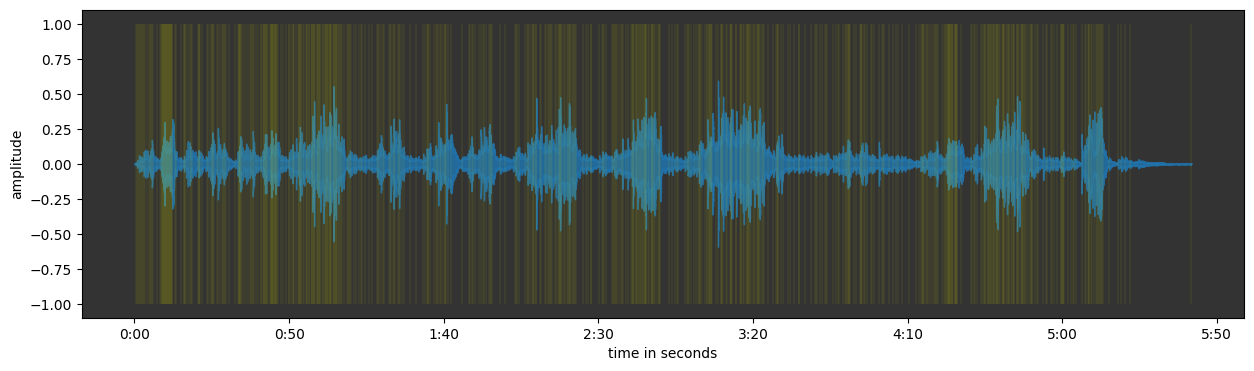

In [360]:
y, sr = librosa.load(classical_audiofile_path)
duration_sec = len(y) / sr
duration_ms = duration_sec * 1000

onsets = librosa.onset.onset_detect(y=y, sr=sr)
onset_times = librosa.frames_to_time(onsets, sr=sr)

# plot everything
plt.figure(figsize=(15, 4))
ax = plt.subplot(1, 1, 1)
ax.set_facecolor("#333333")

librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.8)

ax.vlines(onset_times, -1, 1, linestyle="-", alpha=0.05, color="yellow")
ax.set_xlabel("time in seconds")
ax.set_ylabel("amplitude")

plt.show()

## Exercise 2

In [346]:
# SPLIT AUDIO INTO 5s CHUNKS
audio = AudioSegment.from_mp3(classical_audiofile_path)

chunk_seconds = 5
chunk_length_ms = chunk_seconds * 1000

chunk_paths = []
chunk_onsets = []
for i in range(0, len(audio), chunk_length_ms):
    chunk_id = i // chunk_length_ms
    chunk = audio[i:i + chunk_length_ms]
    chunk_file_name = f"chunk_{chunk_id}.mp3"
    chunk_path = audio_chunks_output_path.joinpath(chunk_file_name)

    chunk.export(chunk_path, format="mp3")
    chunk_paths.append(chunk_path)

    y, sr = librosa.load(chunk_path)
    onsets = librosa.onset.onset_detect(y=y, sr=sr)

    # For ex2
    chunk_onsets.append(len(onsets))
    print(f"chunk {chunk_id} -> nº onsets = {len(onsets)}")

chunk 0 -> nº onsets = 13
chunk 1 -> nº onsets = 19
chunk 2 -> nº onsets = 28
chunk 3 -> nº onsets = 10
chunk 4 -> nº onsets = 12
chunk 5 -> nº onsets = 15
chunk 6 -> nº onsets = 11
chunk 7 -> nº onsets = 15
chunk 8 -> nº onsets = 19
chunk 9 -> nº onsets = 21
chunk 10 -> nº onsets = 19
chunk 11 -> nº onsets = 21
chunk 12 -> nº onsets = 25
chunk 13 -> nº onsets = 14
chunk 14 -> nº onsets = 13
chunk 15 -> nº onsets = 14
chunk 16 -> nº onsets = 16
chunk 17 -> nº onsets = 13
chunk 18 -> nº onsets = 15
chunk 19 -> nº onsets = 13
chunk 20 -> nº onsets = 13
chunk 21 -> nº onsets = 14
chunk 22 -> nº onsets = 17
chunk 23 -> nº onsets = 18
chunk 24 -> nº onsets = 17
chunk 25 -> nº onsets = 15
chunk 26 -> nº onsets = 19
chunk 27 -> nº onsets = 18
chunk 28 -> nº onsets = 18
chunk 29 -> nº onsets = 14
chunk 30 -> nº onsets = 14
chunk 31 -> nº onsets = 20
chunk 32 -> nº onsets = 22
chunk 33 -> nº onsets = 18
chunk 34 -> nº onsets = 18
chunk 35 -> nº onsets = 13
chunk 36 -> nº onsets = 19
chunk 37 ->

In [347]:
# READ FEATURES AND MERGE THEM BY CHUNKS
arff_files = sorted(
    [os.path.join(features_folder_path, f) for f in os.listdir(features_folder_path) if f.endswith(".arff")])

# Read features into df
dfs = []
for f in arff_files:
    data, meta = arff.loadarff(f)
    df = pd.DataFrame(data)
    df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)
    df = df.apply(pd.to_numeric, errors='coerce')
    df.set_index('WindowNumber', inplace=True)
    dfs.append(df)
features_df = pd.concat(dfs, axis=1)
print(features_df)

/var/folders/xg/4_56cwvs3m3bx5jbmw278p_m0000gn/T/ipykernel_8978/1244638929.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.decode() if isinstance(x, bytes) else x)


              Zero-crossing rate  Spectral centroid  Angles in phase domain  \
WindowNumber                                                                  
1.0                     0.000000            -1.0000                0.000000   
2.0                     0.019531          4574.1055                0.049377   
3.0                     0.043945          1127.8739                1.039561   
4.0                     0.005859          1308.8885                1.148613   
5.0                     0.025391          2484.1420                1.029834   
...                          ...                ...                     ...   
14716.0                 0.007812          1398.4568                1.103774   
14717.0                 0.003906          1843.9271                1.029783   
14718.0                 0.005859          1365.7823                1.143510   
14719.0                 0.015625          2085.8660                1.056783   
14720.0                 0.025391          1828.1770 

In [348]:
num_windows = features_df.shape[0]
print(f"Number of feature windows: {num_windows}")
print(f"Duration of piece (ms): {duration_ms:.2f}")

# Calculate exact windows per chunk based on actual number of chunks
num_chunks = len(chunk_paths)
windows_per_chunk = num_windows // num_chunks  # This gives you 213 windows/chunk
remainder_windows = num_windows % num_chunks
print(f"Windows per chunk: {windows_per_chunk}")
print(f"Remainder windows: {remainder_windows}")

# Divide correctly windows in chunks
window_times = np.linspace(0, duration_sec, num_windows, endpoint=False)
chunk_edges = np.arange(0, duration_sec + 5, 5)
chunk_ids = np.digitize(window_times, chunk_edges) - 1  # This is the important step
features_df['chunk_id'] = chunk_ids

# Group and average
avg_features_per_chunk_df = (features_df.groupby('chunk_id').mean(numeric_only=True))
avg_features_per_chunk_df["chunk_onsets"] = chunk_onsets
print(avg_features_per_chunk_df)

Number of feature windows: 14720
Duration of piece (ms): 341812.24
Windows per chunk: 213
Remainder windows: 23
          Zero-crossing rate  Spectral centroid  Angles in phase domain  \
chunk_id                                                                  
0                   0.057893         917.583815                2.674463   
1                   0.053852         663.323933                2.885358   
2                   0.054415         743.179979                2.862371   
3                   0.047924         626.771314                2.867860   
4                   0.042914         587.857687                2.896815   
...                      ...                ...                     ...   
64                  0.025627         487.729617                2.768204   
65                  0.021502         477.777098                2.599721   
66                  0.017487         685.926374                2.089830   
67                  0.014994        1694.978166                

          Zero-crossing rate  Spectral centroid  Angles in phase domain  \
chunk_id                                                                  
0                   0.057893         917.583815                2.674463   
1                   0.053852         663.323933                2.885358   
2                   0.054415         743.179979                2.862371   
3                   0.047924         626.771314                2.867860   
4                   0.042914         587.857687                2.896815   
...                      ...                ...                     ...   
64                  0.025627         487.729617                2.768204   
65                  0.021502         477.777098                2.599721   
66                  0.017487         685.926374                2.089830   
67                  0.014994        1694.978166                1.144837   
68                  0.011268        1894.128749                1.066096   

          Distances in p

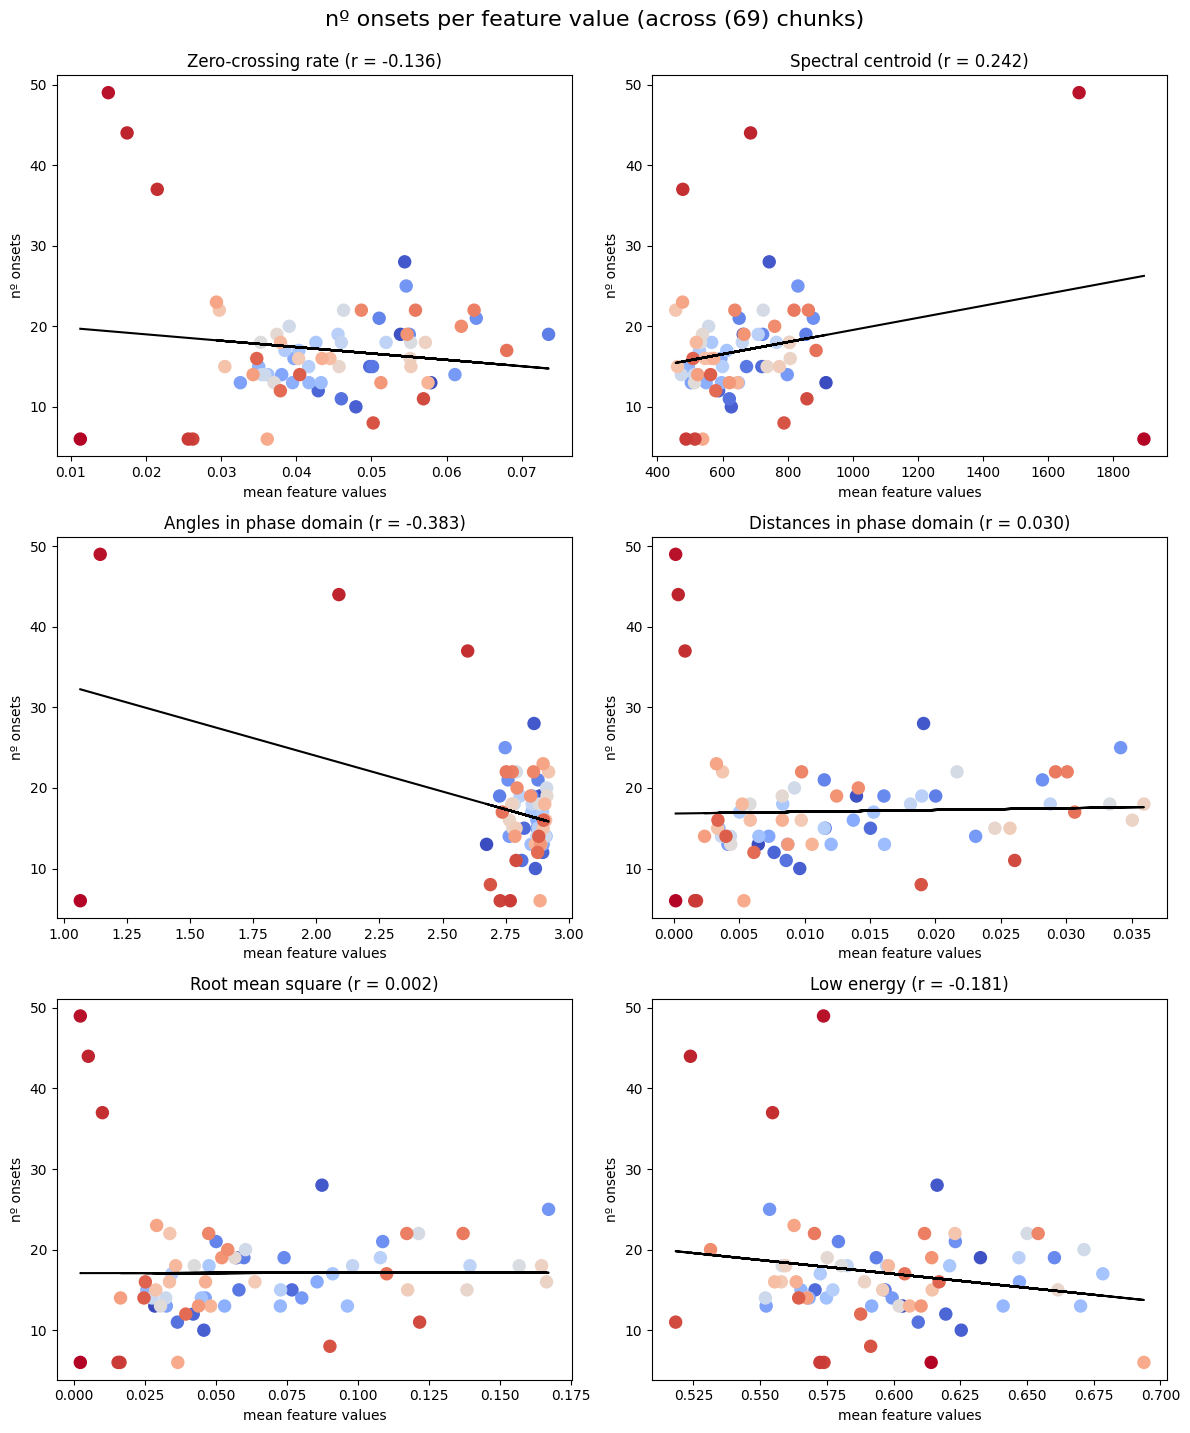

{'Zero-crossing rate': {'r': np.float64(-0.13586168060264284), 'p': np.float64(0.26566330964931895)}, 'Spectral centroid': {'r': np.float64(0.2419246233546877), 'p': np.float64(0.045207258541590904)}, 'Angles in phase domain': {'r': np.float64(-0.38295500095201906), 'p': np.float64(0.0011633688251210853)}, 'Distances in phase domain': {'r': np.float64(0.030119721472803496), 'p': np.float64(0.8059313716710738)}, 'Root mean square': {'r': np.float64(0.0017392692836345526), 'p': np.float64(0.9886835654475561)}, 'Low energy': {'r': np.float64(-0.18123472871838858), 'p': np.float64(0.13614065876704948)}}


In [349]:
# PLOT [nº ONSETS X avg FEATURE VALUE]

def plot_features(df: pd.DataFrame, title: str = "", regression_line: bool = True,
                  feature_column_names: List[str] = None,
                  trim_last_n: int = 0):
    if feature_column_names is None:
        feature_column_names = feature_names

    filtered_df = df.iloc[:-trim_last_n] if trim_last_n > 0 else df

    print(filtered_df)

    regression_value_map = {}

    plt.figure(figsize=(12, 14))
    colors = np.arange(filtered_df.shape[0])
    for f_idx, feature_name in enumerate(feature_column_names):
        plt.subplot(3, 2, f_idx + 1)

        x = np.array(filtered_df[feature_name])
        y = np.array(filtered_df["chunk_onsets"])
        plt.scatter(x, y, c=colors, cmap='coolwarm', marker='o', s=75)

        # Regression Line
        if regression_line:
            slope, intercept, r, p, std_err = stats.linregress(x, y)
            plt.plot(x, slope * x + intercept, color="black", label=f"{r}")

            regression_value_map[feature_name] = {
                "r": r,
                "p": p,
            }
            plt.title(f"{feature_name} (r = {r:.3f})")
        else:
            plt.title(f"{feature_name}")

        plt.xlabel("mean feature values")
        plt.ylabel("nº onsets")
        plt.tight_layout()

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.show()

    print(regression_value_map)

    return regression_value_map


og_correlations = plot_features(avg_features_per_chunk_df,
                                title=f"nº onsets per feature value (across ({len(chunk_onsets)}) chunks)",
                                trim_last_n=TRIM_LAST_N)

## Exercise 3

In [350]:
onset_frames_mask = np.zeros(num_windows, dtype=bool)
non_onset_frames_mask = np.zeros(num_windows, dtype=bool)

ms_per_window = duration_ms / num_windows
print(f"Windows (ms): {ms_per_window:.2f}")


def get_window_id(onset_time_ms: float):
    return int(onset_time_ms // ms_per_window)


prev_window_id = None
for chunk_idx, chunk_path in enumerate(chunk_paths):
    y, sr = librosa.load(chunk_path)
    onsets = librosa.onset.onset_detect(y=y, sr=sr)
    onsets_ms = librosa.frames_to_time(onsets, sr=sr) * 1000

    base_time_ms = chunk_idx * chunk_seconds * 1000
    for onset_ms in onsets_ms:
        window_id = get_window_id(base_time_ms + onset_ms)

        # Mark Onset Frame
        onset_frames_mask[window_id] = True

        # Find middles and mark as non-onset
        if prev_window_id is not None:
            middle_window_id = prev_window_id + ((window_id - prev_window_id) // 2)
            if not onset_frames_mask[middle_window_id]:
                non_onset_frames_mask[middle_window_id] = True

        prev_window_id = window_id

print(f"Overlap: {np.sum(onset_frames_mask & non_onset_frames_mask)}")

features_df['is_onset'] = onset_frames_mask
features_df['is_non_onset'] = non_onset_frames_mask
print(features_df)

Windows (ms): 23.22
Overlap: 0
              Zero-crossing rate  Spectral centroid  Angles in phase domain  \
WindowNumber                                                                  
1.0                     0.000000            -1.0000                0.000000   
2.0                     0.019531          4574.1055                0.049377   
3.0                     0.043945          1127.8739                1.039561   
4.0                     0.005859          1308.8885                1.148613   
5.0                     0.025391          2484.1420                1.029834   
...                          ...                ...                     ...   
14716.0                 0.007812          1398.4568                1.103774   
14717.0                 0.003906          1843.9271                1.029783   
14718.0                 0.005859          1365.7823                1.143510   
14719.0                 0.015625          2085.8660                1.056783   
14720.0              

In [351]:
onset_frames_df = (features_df[features_df['is_onset']]
                   .groupby('chunk_id')
                   .mean(numeric_only=True)
                   .reset_index())
onset_frames_df["chunk_onsets"] = chunk_onsets
print(onset_frames_df)

    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.069636         886.910948                2.702200   
1          1            0.064967         748.896864                2.882550   
2          2            0.059012         801.666917                2.850924   
3          3            0.055664         730.626827                2.854724   
4          4            0.048665         651.118836                2.889170   
..       ...                 ...                ...                     ...   
64        64            0.031250         500.433478                2.780207   
65        65            0.021432         490.496321                2.584118   
66        66            0.015936         649.380346                2.138381   
67        67            0.013831        1659.182082                1.132505   
68        68            0.003581        2179.117050                1.054059   

    Distances in phase domain  Root mean square  Lo

    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.069636         886.910948                2.702200   
1          1            0.064967         748.896864                2.882550   
2          2            0.059012         801.666917                2.850924   
3          3            0.055664         730.626827                2.854724   
4          4            0.048665         651.118836                2.889170   
..       ...                 ...                ...                     ...   
64        64            0.031250         500.433478                2.780207   
65        65            0.021432         490.496321                2.584118   
66        66            0.015936         649.380346                2.138381   
67        67            0.013831        1659.182082                1.132505   
68        68            0.003581        2179.117050                1.054059   

    Distances in phase domain  Root mean square  Lo

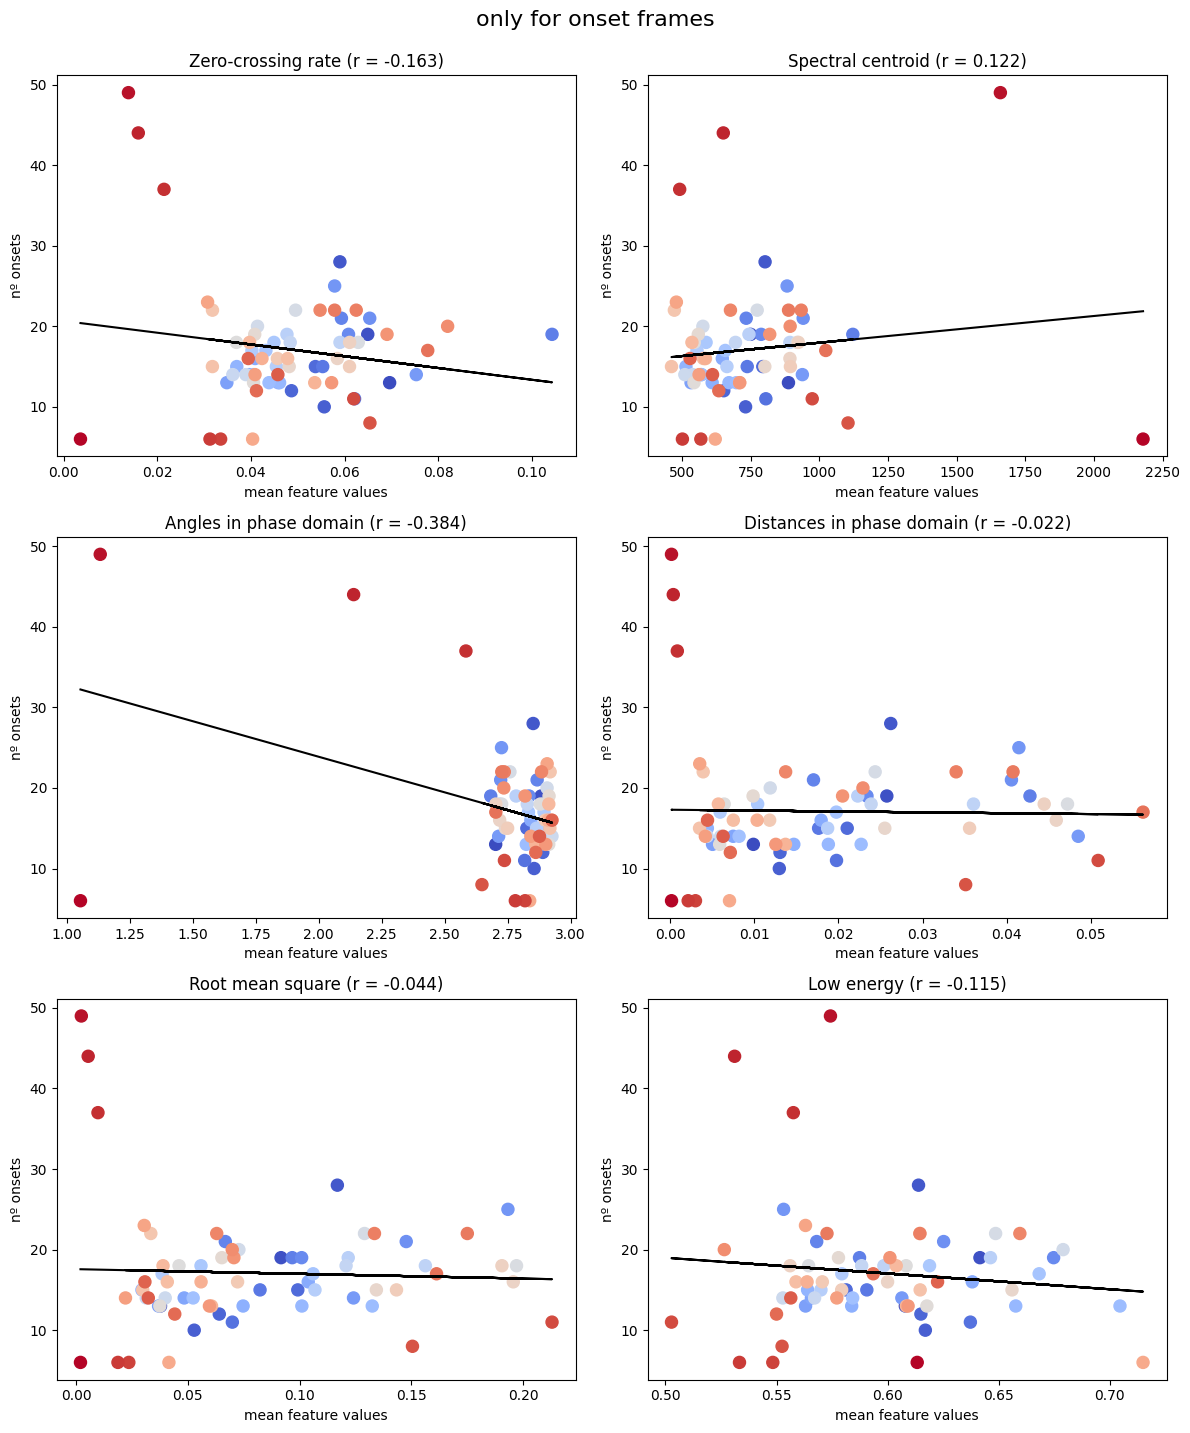

{'Zero-crossing rate': {'r': np.float64(-0.16300623043550713), 'p': np.float64(0.18080998741550408)}, 'Spectral centroid': {'r': np.float64(0.12207989428959938), 'p': np.float64(0.31765437136343244)}, 'Angles in phase domain': {'r': np.float64(-0.38359751579280393), 'p': np.float64(0.0011394504053354527)}, 'Distances in phase domain': {'r': np.float64(-0.021965280671203548), 'p': np.float64(0.8578233674873574)}, 'Root mean square': {'r': np.float64(-0.04361507575577723), 'p': np.float64(0.7219568414692931)}, 'Low energy': {'r': np.float64(-0.11482205344627423), 'p': np.float64(0.3474888992044898)}}


In [352]:
onset_correlations = plot_features(onset_frames_df,
                                   title="only for onset frames",
                                   trim_last_n=TRIM_LAST_N)

In [353]:
non_onset_frames_df = (features_df[features_df['is_non_onset']]
                       .groupby('chunk_id')
                       .mean(numeric_only=True)
                       .reset_index())
non_onset_frames_df["chunk_onsets"] = chunk_onsets
print(non_onset_frames_df)

    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.060096         980.443276                2.710772   
1          1            0.061369         713.579166                2.871441   
2          2            0.057653         774.303744                2.856507   
3          3            0.042081         606.247085                2.867486   
4          4            0.043679         588.629266                2.918719   
..       ...                 ...                ...                     ...   
64        64            0.023763         476.029320                2.750163   
65        65            0.020399         478.029660                2.586767   
66        66            0.018880         672.926633                2.137383   
67        67            0.015107        1767.451016                1.123173   
68        68            0.008594        1640.014680                1.071931   

    Distances in phase domain  Root mean square  Lo

    chunk_id  Zero-crossing rate  Spectral centroid  Angles in phase domain  \
0          0            0.060096         980.443276                2.710772   
1          1            0.061369         713.579166                2.871441   
2          2            0.057653         774.303744                2.856507   
3          3            0.042081         606.247085                2.867486   
4          4            0.043679         588.629266                2.918719   
..       ...                 ...                ...                     ...   
64        64            0.023763         476.029320                2.750163   
65        65            0.020399         478.029660                2.586767   
66        66            0.018880         672.926633                2.137383   
67        67            0.015107        1767.451016                1.123173   
68        68            0.008594        1640.014680                1.071931   

    Distances in phase domain  Root mean square  Lo

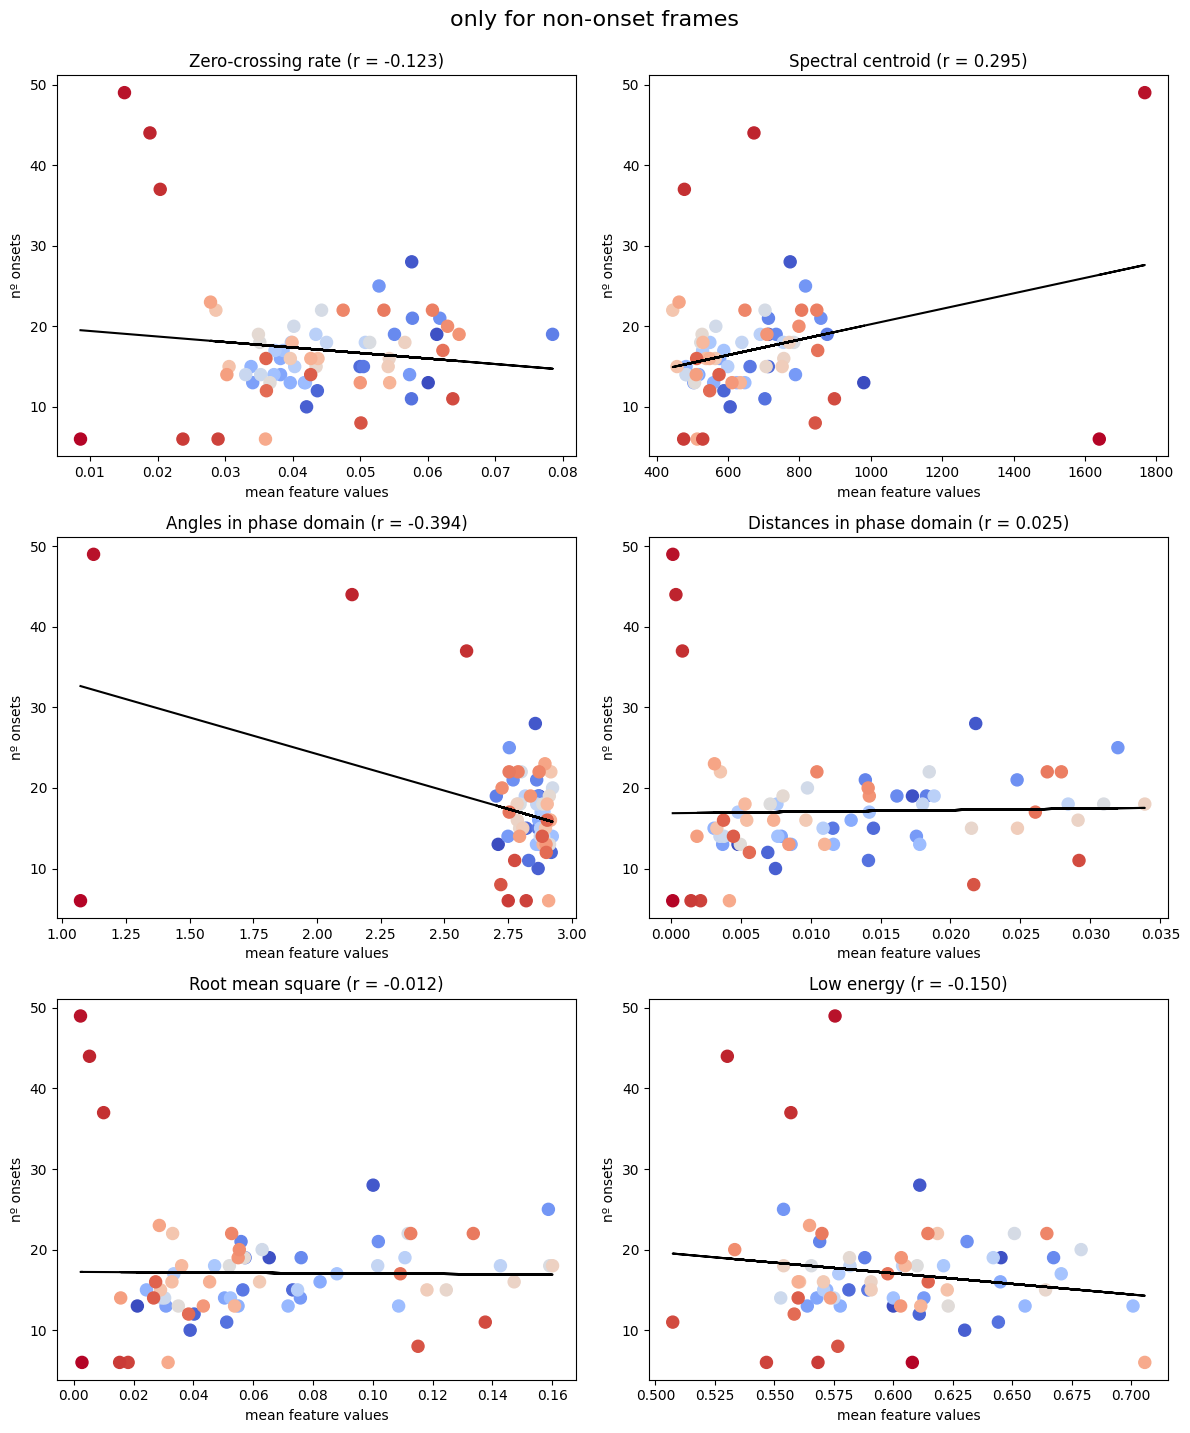

{'Zero-crossing rate': {'r': np.float64(-0.12325964946265633), 'p': np.float64(0.31296472248210194)}, 'Spectral centroid': {'r': np.float64(0.29474720239556956), 'p': np.float64(0.013951520747577254)}, 'Angles in phase domain': {'r': np.float64(-0.39378931052514615), 'p': np.float64(0.0008149592842062822)}, 'Distances in phase domain': {'r': np.float64(0.02464298241935526), 'p': np.float64(0.8407057382727221)}, 'Root mean square': {'r': np.float64(-0.012088176850557079), 'p': np.float64(0.9214708785430799)}, 'Low energy': {'r': np.float64(-0.14977924137179088), 'p': np.float64(0.21930675463035668)}}


In [354]:
non_onset_correlations = plot_features(non_onset_frames_df,
                                       title="only for non-onset frames",
                                       trim_last_n=TRIM_LAST_N)

# Extra: comparing correlations

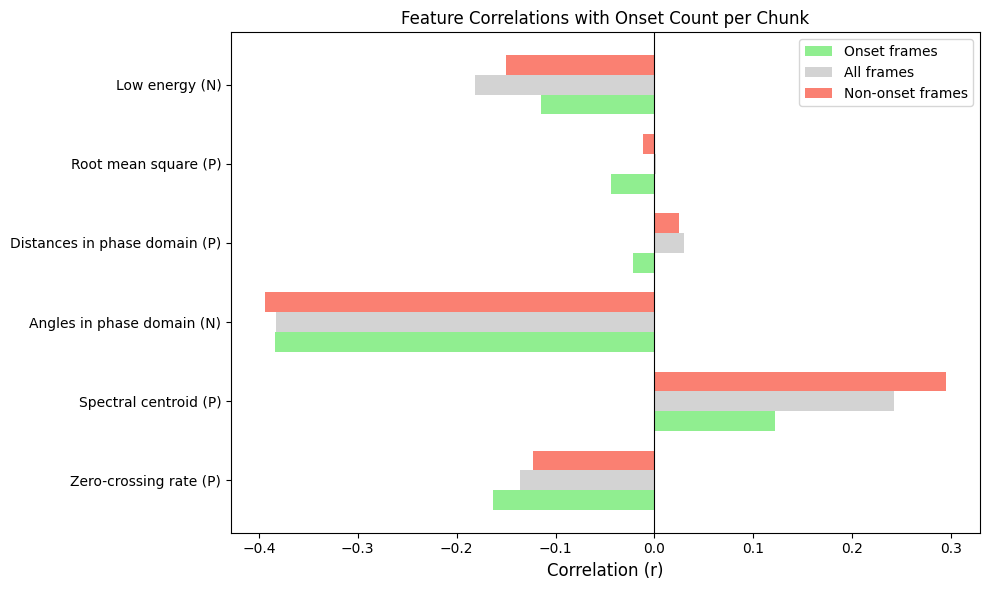

In [355]:
expected_correlation = {
    "Zero-crossing rate": True,
    "Spectral centroid": True,
    "Angles in phase domain": False,
    "Distances in phase domain": True,
    "Root mean square": True,
    "Low energy": False,
}


def plot_correlation_comparison(regression_maps, title="Feature Correlations with Onset Count per Chunk"):
    """
    regression_maps: dict with keys like 'all_frames', 'onset_frames', 'non_onset_frames'
                     each containing {feature_name: {'r': value, 'p': value}}
    """
    features = list(next(iter(regression_maps.values())).keys())

    fig, ax = plt.subplots(figsize=(10, 6))

    x = np.arange(len(features))
    width = 0.25

    colors = ['lightgreen', 'lightgrey', 'salmon']

    for i, (label, data) in enumerate(regression_maps.items()):
        r_values = [data[f]['r'] if f in data else 0 for f in features]
        p_values = [data[f]['p'] if f in data else 1 for f in features]

        ax.barh(x + i * width, r_values, width, label=label, color=colors[i])

    mod_features = [f"{f} (P)" if expected_correlation[f] else f"{f} (N)" for f in features]

    ax.set_xlabel('Correlation (r)', fontsize=12)
    ax.set_yticks(x + width)
    ax.set_yticklabels(mod_features)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# Usage:
correlation_results = {
    'Onset frames': onset_correlations,
    'All frames': og_correlations,
    'Non-onset frames': non_onset_correlations
}
plot_correlation_comparison(correlation_results)

In [356]:
# Compare mean feature levels across categories
mean_onset = features_df.loc[features_df['is_onset'], feature_names].mean()
mean_nononset = features_df.loc[features_df['is_non_onset'], feature_names].mean()

comparison = pd.DataFrame({
    "onset_mean": mean_onset,
    "non_onset_mean": mean_nononset,
    "difference": mean_onset - mean_nononset
})
print(comparison.sort_values("difference"))

                           onset_mean  non_onset_mean  difference
Angles in phase domain       2.716281        2.731013   -0.014733
Low energy                   0.594514        0.595922   -0.001408
Zero-crossing rate           0.047679        0.043245    0.004434
Distances in phase domain    0.017927        0.012377    0.005550
Root mean square             0.080253        0.064584    0.015669
Spectral centroid          753.110335      698.056293   55.054041
